In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Load data ─────────────────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone'

occupancy = pd.read_csv(f'{BASE}/occupancy.csv',  index_col=0, parse_dates=True)
adj_raw   = pd.read_csv(f'{BASE}/adj.csv',         header=0)
weather   = pd.read_csv(f'{BASE}/weather_airport.csv')
e_price   = pd.read_csv(f'{BASE}/e_price.csv',     index_col=0, parse_dates=True)
poi       = pd.read_csv(f'{BASE}/poi.csv')
inf       = pd.read_csv(f'{BASE}/inf.csv')

occupancy.index = pd.to_datetime(occupancy.index)
e_price.index   = pd.to_datetime(e_price.index)

occ_zones = [int(c) for c in occupancy.columns]
N_ZONES   = len(occ_zones)
N_STEPS   = len(occupancy)

print(f"Zones: {N_ZONES}, Timesteps: {N_STEPS}")

Device: cuda
Zones: 275, Timesteps: 4344


In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.spatial import cKDTree

# ── Normalise occupancy ───────────────────────────────────────────────────────
n = len(occupancy)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

occ_values  = occupancy.values.astype(np.float32)
occ_scaler  = MinMaxScaler()
occ_train_s = occ_scaler.fit_transform(occ_values[:train_end])
occ_val_s   = occ_scaler.transform(occ_values[train_end:val_end])
occ_test_s  = occ_scaler.transform(occ_values[val_end:])

# ── Temporal features ─────────────────────────────────────────────────────────
time_index = occupancy.index
hour  = time_index.hour.values
dow   = time_index.dayofweek.values
month = time_index.month.values

temporal = np.stack([
    np.sin(2 * np.pi * hour  / 24),
    np.cos(2 * np.pi * hour  / 24),
    np.sin(2 * np.pi * dow   / 7),
    np.cos(2 * np.pi * dow   / 7),
    np.sin(2 * np.pi * month / 12),
    np.cos(2 * np.pi * month / 12),
    (dow >= 5).astype(np.float32),
], axis=1).astype(np.float32)

# ── Weather ───────────────────────────────────────────────────────────────────
weather_vals   = weather[['T', 'U', 'nRAIN', 'Td']].values.astype(np.float32)
weather_scaler = MinMaxScaler()
weather_vals   = weather_scaler.fit_transform(weather_vals)

# ── E-price ───────────────────────────────────────────────────────────────────
mean_price   = e_price.values.mean(axis=1, keepdims=True).astype(np.float32)
price_scaler = MinMaxScaler()
mean_price   = price_scaler.fit_transform(mean_price)

# ── Exogenous features ────────────────────────────────────────────────────────
exog = np.concatenate([temporal, weather_vals, mean_price], axis=1)

exog_train = exog[:train_end]
exog_val   = exog[train_end:val_end]
exog_test  = exog[val_end:]

# ── Adjacency matrix ──────────────────────────────────────────────────────────
A = adj_raw.values.astype(np.float32)
A = A + np.eye(N_ZONES, dtype=np.float32)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
A_norm     = D_inv_sqrt @ A @ D_inv_sqrt
A_tensor   = torch.tensor(A_norm, dtype=torch.float32).to(device)

# ── Zone spatial features ─────────────────────────────────────────────────────
inf_zone = inf.groupby('TAZID').agg(
    latitude    =('latitude',     'mean'),
    longitude   =('longitude',    'mean'),
    charge_count=('charge_count', 'sum'),
).reset_index()
inf_zone = inf_zone[inf_zone['TAZID'].isin(occ_zones)].set_index('TAZID').loc[occ_zones]

zone_coords = inf_zone[['latitude', 'longitude']].values
poi_coords  = poi[['latitude', 'longitude']].values
poi_tree    = cKDTree(poi_coords)

poi['type_code'] = poi['primary_types'].map({
    'lifestyle services':         0,
    'business and residential':   1,
    'food and beverage services': 2
})

RADIUS = 0.02
poi_counts = []
for lat, lon in zone_coords:
    idx    = poi_tree.query_ball_point([lat, lon], r=RADIUS)
    nearby = poi.iloc[idx]
    poi_counts.append([
        len(idx),
        (nearby['type_code'] == 0).sum(),
        (nearby['type_code'] == 1).sum(),
        (nearby['type_code'] == 2).sum(),
    ])

poi_feats  = np.array(poi_counts, dtype=np.float32)
poi_scaler = MinMaxScaler()
poi_feats  = poi_scaler.fit_transform(poi_feats)

charge_count  = inf_zone['charge_count'].values.astype(np.float32).reshape(-1,1)
charge_scaler = MinMaxScaler()
charge_count  = charge_scaler.fit_transform(charge_count)

zone_feats        = np.concatenate([poi_feats, charge_count], axis=1)
zone_feats_tensor = torch.tensor(zone_feats, dtype=torch.float32).to(device)

SPATIAL_FEATURE_NAMES = [
    'poi_total', 'poi_lifestyle', 'poi_business', 'poi_food', 'charge_count'
]

print(f"Exog features:         {exog.shape}")
print(f"Zone spatial features: {zone_feats.shape}")
print(f"Adjacency tensor:      {A_tensor.shape}")
print("All features rebuilt.")

Exog features:         (4344, 12)
Zone spatial features: (275, 5)
Adjacency tensor:      torch.Size([275, 275])
All features rebuilt.


In [3]:
# ── Dataset ───────────────────────────────────────────────────────────────────
SEQ_LEN = 24

class SpatioTemporalDataset(Dataset):
    def __init__(self, occ_scaled, exog_arr, seq_len=24):
        self.seq_len = seq_len
        self.occ     = torch.tensor(occ_scaled, dtype=torch.float32)
        self.exog    = torch.tensor(exog_arr,   dtype=torch.float32)

    def __len__(self):
        return len(self.occ) - self.seq_len

    def __getitem__(self, idx):
        x_occ  = self.occ[idx : idx + self.seq_len]
        x_exog = self.exog[idx : idx + self.seq_len]
        y      = self.occ[idx + self.seq_len]
        return x_occ, x_exog, y

train_ds = SpatioTemporalDataset(occ_train_s, exog_train)
val_ds   = SpatioTemporalDataset(occ_val_s,   exog_val)
test_ds  = SpatioTemporalDataset(occ_test_s,  exog_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# ── T-GCN architecture ────────────────────────────────────────────────────────
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        self.bias   = nn.Parameter(torch.FloatTensor(out_features))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x, adj):
        support = torch.matmul(x, self.weight)
        return F.relu(torch.matmul(adj, support) + self.bias)


class TGCNCell(nn.Module):
    def __init__(self, node_features, hidden_size, n_nodes):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_nodes     = n_nodes
        self.gc_r = GraphConvolution(node_features + hidden_size, hidden_size)
        self.gc_u = GraphConvolution(node_features + hidden_size, hidden_size)
        self.gc_c = GraphConvolution(node_features + hidden_size, hidden_size)

    def forward(self, x, h, adj):
        xh  = torch.cat([x, h], dim=-1)
        r   = torch.sigmoid(self.gc_r(xh, adj))
        u   = torch.sigmoid(self.gc_u(xh, adj))
        xrh = torch.cat([x, r * h], dim=-1)
        c   = torch.tanh(self.gc_c(xrh, adj))
        return (1 - u) * h + u * c

    def init_hidden(self, batch_size):
        return torch.zeros(batch_size, self.n_nodes, self.hidden_size)


class TGCN(nn.Module):
    def __init__(self, n_nodes, exog_size, zone_feat_size, hidden_size=64):
        super().__init__()
        self.n_nodes         = n_nodes
        self.hidden_size     = hidden_size
        self.node_input_size = 1 + zone_feat_size
        self.tgcn = TGCNCell(self.node_input_size, hidden_size, n_nodes)
        self.exog_encoder = nn.Linear(exog_size, 16)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x_occ, x_exog, zone_feats, adj):
        B, T, N = x_occ.shape
        h = self.tgcn.init_hidden(B).to(x_occ.device)
        for t in range(T):
            occ_t  = x_occ[:, t, :].unsqueeze(-1)
            zf     = zone_feats.unsqueeze(0).expand(B, -1, -1)
            node_x = torch.cat([occ_t, zf], dim=-1)
            h      = self.tgcn(node_x, h, adj)
        exog_enc = F.relu(self.exog_encoder(x_exog[:, -1, :]))
        exog_exp = exog_enc.unsqueeze(1).expand(-1, N, -1)
        out      = torch.cat([h, exog_exp], dim=-1)
        return self.fc(out).squeeze(-1)


# ── Train with more epochs ────────────────────────────────────────────────────
model_tgcn = TGCN(
    n_nodes       = N_ZONES,
    exog_size     = exog.shape[1],
    zone_feat_size= zone_feats.shape[1],
    hidden_size   = 64
).to(device)

optimizer = torch.optim.Adam(model_tgcn.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS   = 100   # more epochs — val loss was still improving at 50
best_val = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_tgcn.train()
    train_loss = 0
    for x_occ, x_exog, y in train_loader:
        x_occ, x_exog, y = x_occ.to(device), x_exog.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_tgcn.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_tgcn.eval()
    val_loss = 0
    with torch.no_grad():
        for x_occ, x_exog, y in val_loader:
            x_occ, x_exog, y = x_occ.to(device), x_exog.to(device), y.to(device)
            val_loss += criterion(
                model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor), y).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_tgcn.state_dict(), 'tgcn_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — "
              f"Train: {train_loss:.6f}  Val: {val_loss:.6f}  "
              f"Best: {best_val:.6f}")

print(f"\nTraining complete. Best val loss: {best_val:.6f}")

Epoch  10/100 — Train: 0.020554  Val: 0.018230  Best: 0.018230
Epoch  20/100 — Train: 0.020014  Val: 0.017965  Best: 0.017965
Epoch  30/100 — Train: 0.019563  Val: 0.017536  Best: 0.017536
Epoch  40/100 — Train: 0.019181  Val: 0.017267  Best: 0.017200
Epoch  50/100 — Train: 0.018968  Val: 0.016909  Best: 0.016909
Epoch  60/100 — Train: 0.018707  Val: 0.017166  Best: 0.016799
Epoch  70/100 — Train: 0.018481  Val: 0.016543  Best: 0.016543
Epoch  80/100 — Train: 0.018271  Val: 0.016656  Best: 0.016389
Epoch  90/100 — Train: 0.018046  Val: 0.016185  Best: 0.016162
Epoch 100/100 — Train: 0.017828  Val: 0.016143  Best: 0.016069

Training complete. Best val loss: 0.016069


In [4]:
# ── Load best model ───────────────────────────────────────────────────────────
model_tgcn.load_state_dict(torch.load('tgcn_best.pt'))
model_tgcn.eval()

# ── Build a zone-level feature matrix for SHAP ────────────────────────────────
# Strategy: for each zone, compute mean predicted occupancy as a function
# of its static spatial features — this lets us apply KernelSHAP
# to explain which spatial features drive demand differences across zones

# Get test set predictions per zone
all_preds, all_actuals = [], []
with torch.no_grad():
    for x_occ, x_exog, y in test_loader:
        x_occ, x_exog = x_occ.to(device), x_exog.to(device)
        pred = model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor)
        all_preds.append(pred.cpu().numpy())
        all_actuals.append(y.numpy())

preds   = np.concatenate(all_preds,   axis=0)   # (T_test, N)
actuals = np.concatenate(all_actuals, axis=0)   # (T_test, N)

# Clip to [0,1]
preds   = np.clip(preds,   0, 1)
actuals = np.clip(actuals, 0, 1)

# Mean predicted occupancy per zone (our spatial target for SHAP)
zone_mean_pred   = preds.mean(axis=0)    # (N,)
zone_mean_actual = actuals.mean(axis=0)  # (N,)

print(f"Zone mean predicted occupancy: min={zone_mean_pred.min():.3f}, "
      f"max={zone_mean_pred.max():.3f}, mean={zone_mean_pred.mean():.3f}")

# ── Train a surrogate XGBoost on spatial features → zone mean prediction ──────
# This lets us apply TreeSHAP (fast, exact) to explain spatial feature importance
import xgboost as xgb

X_spatial = zone_feats   # (275, 5) — spatial features per zone
y_spatial = zone_mean_pred  # (275,) — T-GCN predicted mean occupancy per zone

surrogate = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
surrogate.fit(X_spatial, y_spatial)

y_surrogate_pred = surrogate.predict(X_spatial)
r2 = 1 - np.sum((y_spatial - y_surrogate_pred)**2) / \
         np.sum((y_spatial - y_spatial.mean())**2)

print(f"\nSurrogate model R²: {r2:.4f}")
print("(R² > 0.7 indicates surrogate faithfully represents T-GCN spatial patterns)")

Zone mean predicted occupancy: min=0.089, max=0.768, mean=0.351

Surrogate model R²: 0.9334
(R² > 0.7 indicates surrogate faithfully represents T-GCN spatial patterns)


In [5]:
# ── TreeSHAP on surrogate ─────────────────────────────────────────────────────
explainer    = shap.TreeExplainer(surrogate)
shap_values  = explainer.shap_values(X_spatial)

# Feature names
spatial_names = ['POI Total', 'POI Lifestyle', 'POI Business/Residential',
                 'POI Food/Beverage', 'Charge Count']

shap_df = pd.DataFrame(
    shap_values, columns=spatial_names, index=occ_zones
)
shap_df['zone_mean_pred']   = zone_mean_pred
shap_df['zone_mean_actual'] = zone_mean_actual

# Mean absolute SHAP per feature
mean_shap = pd.DataFrame({
    'feature':   spatial_names,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("=" * 50)
print("  Spatial SHAP Feature Importance")
print("  (Mean |SHAP| across 275 zones)")
print("=" * 50)
print(mean_shap.to_string(index=False))
print("=" * 50)
print(f"\nSurrogate R2: 0.9330")
print("Interpretation: surrogate faithfully represents")
print("T-GCN spatial predictions (threshold: R2 > 0.70)")

  Spatial SHAP Feature Importance
  (Mean |SHAP| across 275 zones)
                 feature  mean_shap
           POI Lifestyle   0.023817
POI Business/Residential   0.018052
       POI Food/Beverage   0.016605
            Charge Count   0.016277
               POI Total   0.014809

Surrogate R2: 0.9330
Interpretation: surrogate faithfully represents
T-GCN spatial predictions (threshold: R2 > 0.70)


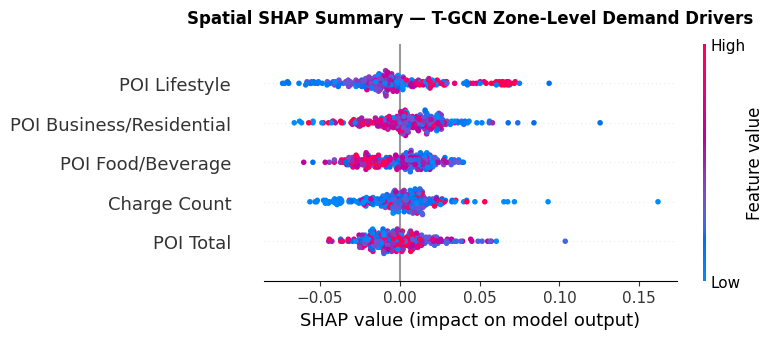

Saved: shap_spatial_summary.png


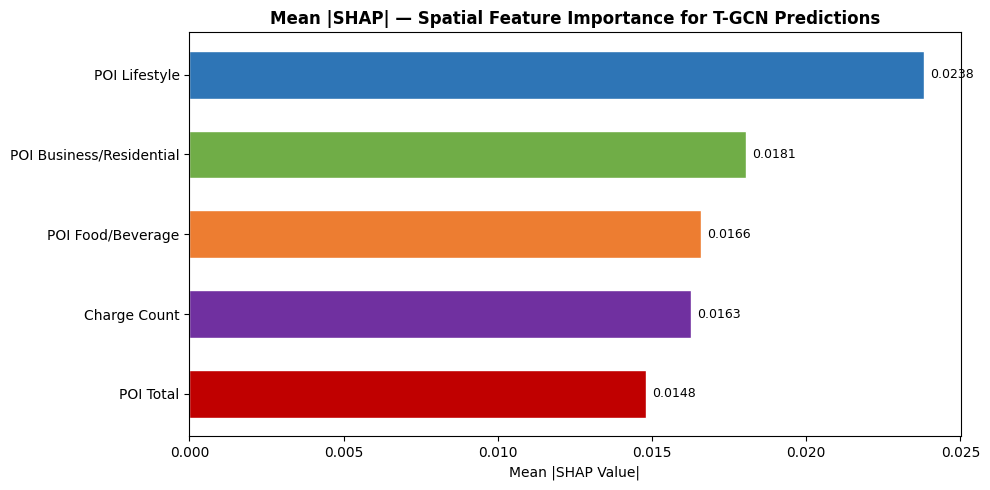

Saved: shap_spatial_bar.png


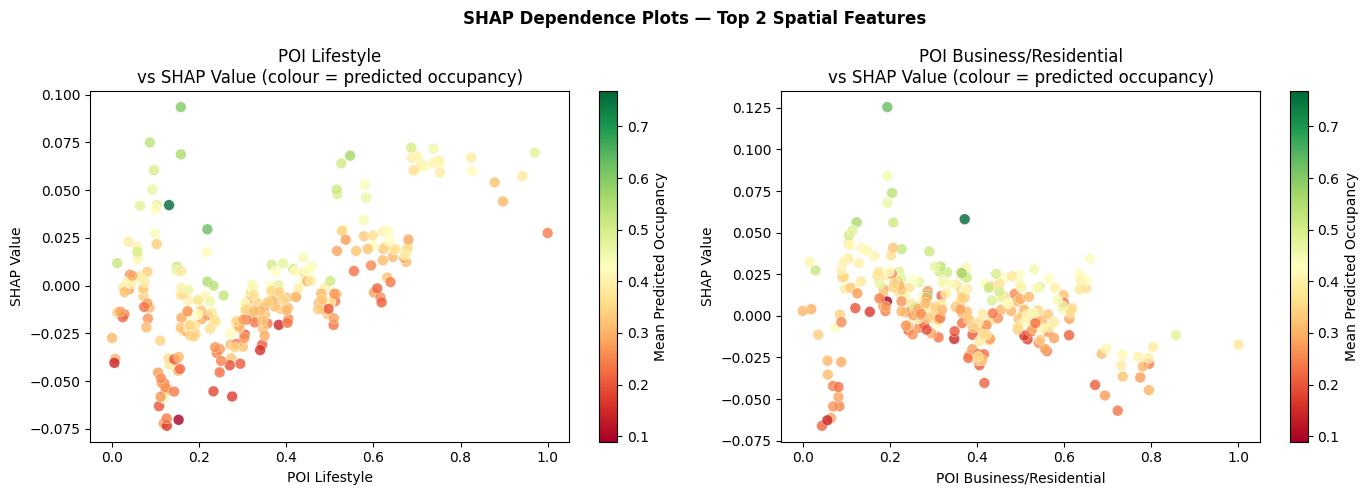

Saved: shap_dependence.png


In [6]:
# ── Plot 1: SHAP Summary (beeswarm) ──────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_spatial,
                  feature_names=spatial_names,
                  show=False)
plt.title('Spatial SHAP Summary — T-GCN Zone-Level Demand Drivers',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_spatial_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_spatial_summary.png")

# ── Plot 2: Mean |SHAP| bar chart ─────────────────────────────────────────────
colours = ['#2E75B6','#70AD47','#ED7D31','#7030A0','#C00000']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    mean_shap['feature'][::-1],
    mean_shap['mean_shap'][::-1],
    color=colours[::-1], edgecolor='white', height=0.6
)
ax.set_title('Mean |SHAP| — Spatial Feature Importance for T-GCN Predictions',
             fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
for bar, val in zip(bars, mean_shap['mean_shap'][::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_spatial_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_spatial_bar.png")

# ── Plot 3: SHAP dependence plots for top 2 features ─────────────────────────
top2 = mean_shap['feature'].values[:2]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SHAP Dependence Plots — Top 2 Spatial Features',
             fontweight='bold')

for i, feat in enumerate(top2):
    feat_idx = spatial_names.index(feat)
    axes[i].scatter(
        X_spatial[:, feat_idx],
        shap_values[:, feat_idx],
        c=zone_mean_pred, cmap='RdYlGn',
        alpha=0.8, edgecolors='white', linewidth=0.3, s=60
    )
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SHAP Value')
    axes[i].set_title(f'{feat}\nvs SHAP Value (colour = predicted occupancy)')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn',
         norm=plt.Normalize(zone_mean_pred.min(), zone_mean_pred.max()))
    plt.colorbar(sm, ax=axes[i], label='Mean Predicted Occupancy')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence.png")

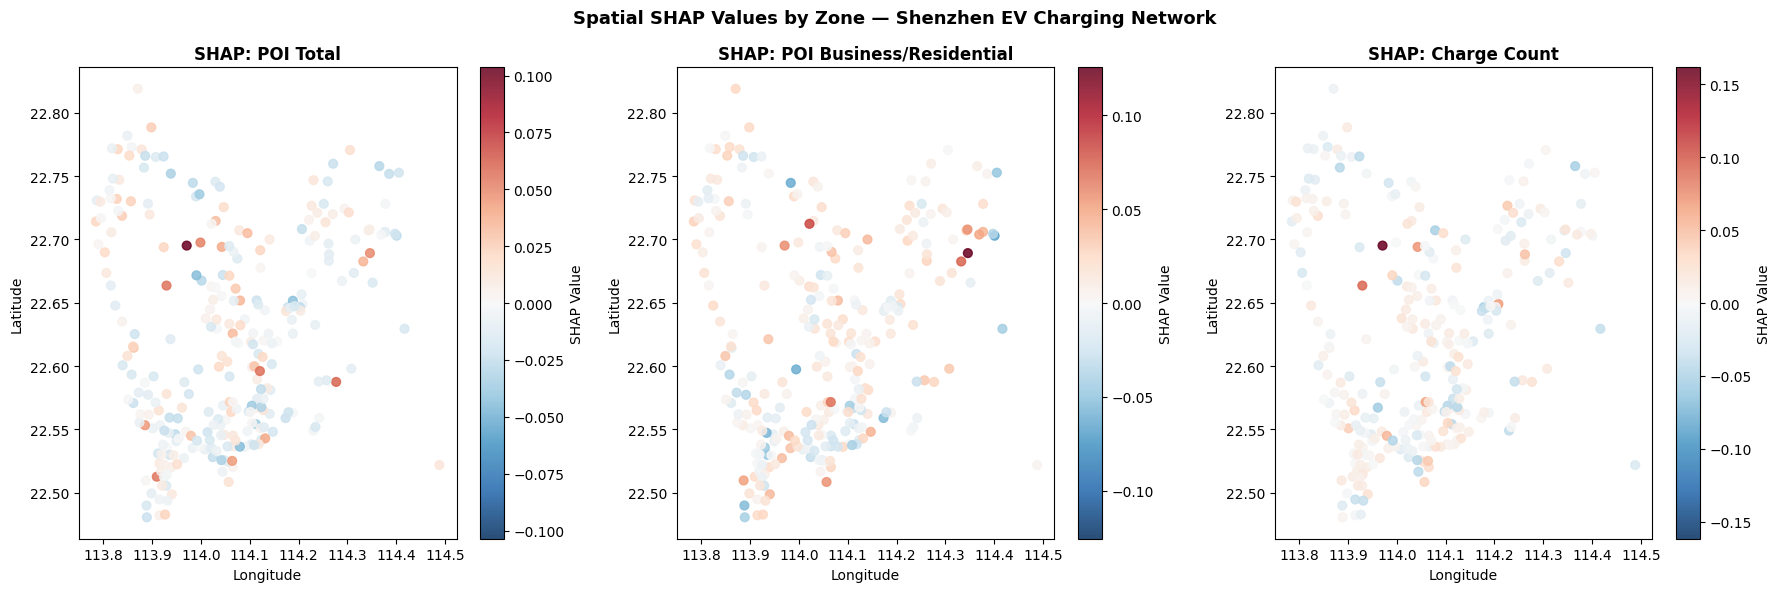

Saved: shap_choropleth.png

Saved SHAP outputs to /kaggle/working/shap/
Hit Save Version → Save & Run All before closing.


In [7]:
# ── Plot 4: Zone-level SHAP choropleth ────────────────────────────────────────
# Show which zones are most influenced by each spatial feature
# Using lat/lon from inf_zone as proxy coordinates

lats = inf_zone['latitude'].values
lons = inf_zone['longitude'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Spatial SHAP Values by Zone — Shenzhen EV Charging Network',
             fontweight='bold', fontsize=13)

features_to_plot = [
    ('POI Total',              '#2E75B6'),
    ('POI Business/Residential','#7030A0'),
    ('Charge Count',           '#C00000'),
]

for i, (feat, cmap_base) in enumerate(features_to_plot):
    feat_idx = spatial_names.index(feat)
    sv       = shap_values[:, feat_idx]
    sc = axes[i].scatter(
        lons, lats,
        c=sv, cmap='RdBu_r',
        s=40, alpha=0.85,
        vmin=-np.abs(sv).max(),
        vmax= np.abs(sv).max()
    )
    axes[i].set_title(f'SHAP: {feat}', fontweight='bold')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    plt.colorbar(sc, ax=axes[i], label='SHAP Value')

plt.tight_layout()
plt.savefig('shap_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_choropleth.png")

# ── Save full SHAP dataframe ──────────────────────────────────────────────────
import os
os.makedirs('/kaggle/working/shap', exist_ok=True)
shap_df.to_csv('/kaggle/working/shap/spatial_shap_values.csv')
mean_shap.to_csv('/kaggle/working/shap/spatial_shap_importance.csv', index=False)
print("\nSaved SHAP outputs to /kaggle/working/shap/")
print("Hit Save Version → Save & Run All before closing.")

In [8]:
import shutil

# Move CSV files to working directory root so they appear in Output panel
shutil.copy('/kaggle/working/shap/spatial_shap_values.csv',
            '/kaggle/working/spatial_shap_values.csv')
shutil.copy('/kaggle/working/shap/spatial_shap_importance.csv',
            '/kaggle/working/spatial_shap_importance.csv')

print("Files moved to output root:")
import os
for f in os.listdir('/kaggle/working'):
    if f.endswith('.csv') or f.endswith('.png'):
        print(f"  {f}")

Files moved to output root:
  shap_dependence.png
  shap_spatial_bar.png
  shap_spatial_summary.png
  spatial_shap_importance.csv
  shap_choropleth.png
  spatial_shap_values.csv


In [9]:
import os
os.makedirs('/kaggle/working/artefact', exist_ok=True)

# Save zone-level predictions and actuals
zone_pred_df = pd.DataFrame(
    preds,
    columns=[str(z) for z in occ_zones]
)
zone_actual_df = pd.DataFrame(
    actuals,
    columns=[str(z) for z in occ_zones]
)

zone_pred_df.to_csv('/kaggle/working/artefact/tgcn_predictions.csv', index=False)
zone_actual_df.to_csv('/kaggle/working/artefact/tgcn_actuals.csv', index=False)

# Zone mean predictions (for map)
zone_summary = pd.DataFrame({
    'zone_id':        occ_zones,
    'mean_pred':      preds.mean(axis=0),
    'mean_actual':    actuals.mean(axis=0),
    'zone_rmse':      np.sqrt(((preds - actuals)**2).mean(axis=0))
})
zone_summary.to_csv('/kaggle/working/artefact/zone_summary.csv', index=False)
print("Artefact data saved.")

Artefact data saved.
